# Single-GPU Training Techniques

## Efficient Training with Mixed Precision, Gradient Checkpointing & Accumulation

**Scenario**: A computational biology lab is training a deep classifier to predict **protein subcellular localization** (nucleus, cytoplasm, membrane, secreted, mitochondria) from amino acid composition features. The model is too large for a single GPU's memory at full batch size.

We combine **four memory-saving techniques** into a single training pipeline to fit larger models on limited hardware:

| Technique | What it does | Trade-off |
|-----------|-------------|-----------|
| **Mixed Precision** | Use bfloat16 for activations, float32 for params | ~2x memory savings on activations |
| **Gradient Checkpointing** | Recompute activations during backward pass | Memory ↓, compute ↑ (~30%) |
| **Gradient Accumulation** | Process mini-batches, accumulate gradients | Simulates large batch in small memory |
| **Buffer Donation** | Reuse input buffers for outputs | Reduces peak memory allocation |

Based on the [UvA DLC Single-GPU Techniques tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/scaling/JAX/single_gpu_techniques.html).

In [1]:
import jax
import jax.numpy as jnp
from jax import random
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
import matplotlib as mpl
from typing import Any, Callable, NamedTuple, Tuple
from functools import partial
import time

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.9.0.1
Devices: [CpuDevice(id=0)]


---

## 1 — Dataset: Protein Subcellular Localization

We generate synthetic amino acid composition vectors for 4,096 proteins. Each protein is represented by a **128-dimensional feature vector** (composition, dipeptide frequencies, physicochemical properties). The task is 5-class classification.

In [2]:
class Batch(NamedTuple):
    """Container for a batch of data (NamedTuple = automatic JAX pytree)."""
    inputs: jax.Array
    labels: jax.Array


# --- Configuration ---
N_SAMPLES = 4096
N_FEATURES = 128
N_CLASSES = 5
CLASS_NAMES = ["Nucleus", "Cytoplasm", "Membrane", "Secreted", "Mitochondria"]

# --- Generate synthetic protein features ---
key = random.PRNGKey(42)
key, data_key, label_key = random.split(key, 3)

# Each class has a distinct mean direction in feature space
class_centers = random.normal(data_key, (N_CLASSES, N_FEATURES)) * 1.5

# Assign labels uniformly, then generate features around class centers
labels = random.randint(label_key, (N_SAMPLES,), 0, N_CLASSES)

key, noise_key = random.split(key)
noise = random.normal(noise_key, (N_SAMPLES, N_FEATURES)) * 1.0
X = class_centers[labels] + noise  # features clustered around class centers

# Train / validation split (75/25)
n_train = 3072
train_batch = Batch(inputs=X[:n_train], labels=labels[:n_train])
val_batch = Batch(inputs=X[n_train:], labels=labels[n_train:])

print(f"Training:   {n_train} proteins × {N_FEATURES} features → {N_CLASSES} classes")
print(f"Validation: {N_SAMPLES - n_train} proteins")
print(f"Class distribution (train): {dict(zip(CLASS_NAMES, [int((train_batch.labels == i).sum()) for i in range(N_CLASSES)]))}")

Training:   3072 proteins × 128 features → 5 classes
Validation: 1024 proteins
Class distribution (train): {'Nucleus': 594, 'Cytoplasm': 639, 'Membrane': 625, 'Secreted': 613, 'Mitochondria': 601}


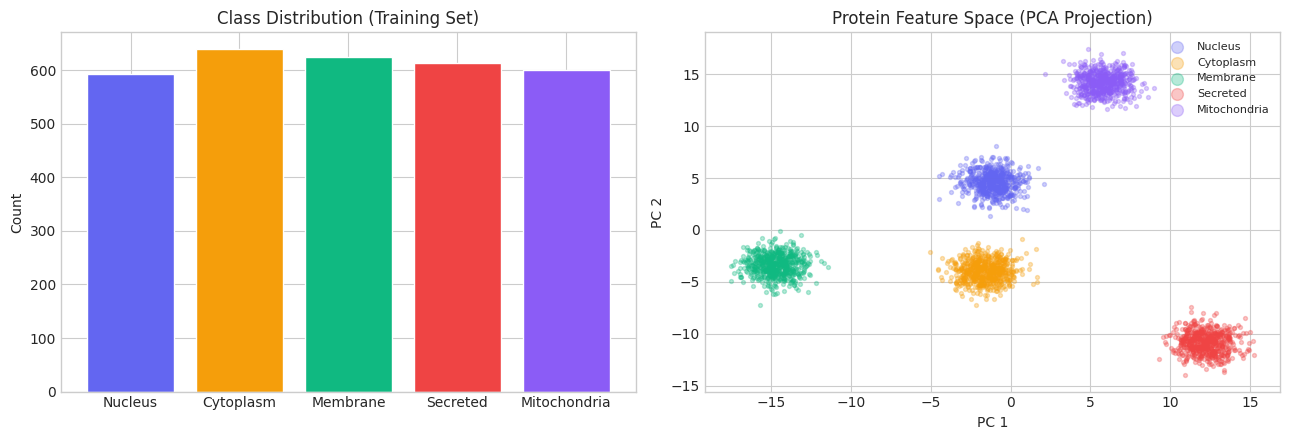

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = ["#6366f1", "#f59e0b", "#10b981", "#ef4444", "#8b5cf6"]

# Class distribution
counts = [int((train_batch.labels == i).sum()) for i in range(N_CLASSES)]
axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor="white")
axes[0].set_ylabel("Count")
axes[0].set_title("Class Distribution (Training Set)")

# 2D PCA-like projection (using first 2 principal directions)
X_centered = train_batch.inputs - train_batch.inputs.mean(axis=0)
U, S, Vt = jnp.linalg.svd(X_centered, full_matrices=False)
X_proj = X_centered @ Vt[:2].T

for i in range(N_CLASSES):
    mask = train_batch.labels == i
    axes[1].scatter(X_proj[mask, 0], X_proj[mask, 1], alpha=0.3, s=8,
                    color=colors[i], label=CLASS_NAMES[i])
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].set_title("Protein Feature Space (PCA Projection)")
axes[1].legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()

---

## 2 — Baseline Model (float32)

A standard MLP classifier built with Flax. The `dtype` parameter controls the precision of activations — we start with `float32` as the baseline, then switch to `bfloat16` in the next section.

$$\hat{y} = \text{softmax}\left(W_3 \cdot \sigma\left(W_2 \cdot \sigma\left(W_1 x + b_1\right) + b_2\right) + b_3\right)$$

In [4]:
class ProteinClassifier(nn.Module):
    """MLP classifier with configurable precision."""
    hidden_size: int = 256
    num_classes: int = 5
    dropout_rate: float = 0.1
    dtype: Any = jnp.float32  # activation dtype (float32 or bfloat16)

    @nn.compact
    def __call__(self, x: jax.Array, train: bool) -> jax.Array:
        # Layer 1
        x = nn.Dense(self.hidden_size, dtype=self.dtype)(x)
        x = nn.LayerNorm(dtype=self.dtype)(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        # Layer 2
        x = nn.Dense(self.hidden_size, dtype=self.dtype)(x)
        x = nn.LayerNorm(dtype=self.dtype)(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        # Output — always compute in float32 for numerical stability
        x = nn.Dense(self.num_classes, dtype=self.dtype)(x)
        x = x.astype(jnp.float32)
        return nn.log_softmax(x, axis=-1)


# Initialize baseline model (float32)
model_f32 = ProteinClassifier(dtype=jnp.float32)
key, init_key = random.split(key)
variables = model_f32.init(init_key, jnp.ones((1, N_FEATURES)), train=False)
params = variables["params"]

n_params = sum(p.size for p in jax.tree.leaves(params))
print(f"Parameters: {n_params:,}")
print(f"Parameter dtypes: {set(p.dtype for p in jax.tree.leaves(params))}")
print(f"\nArchitecture:")
print(jax.tree.map(lambda x: f"{x.shape} ({x.dtype})", params))

Parameters: 101,125
Parameter dtypes: {dtype('float32')}

Architecture:
{'Dense_0': {'bias': '(256,) (float32)', 'kernel': '(128, 256) (float32)'}, 'Dense_1': {'bias': '(256,) (float32)', 'kernel': '(256, 256) (float32)'}, 'Dense_2': {'bias': '(5,) (float32)', 'kernel': '(256, 5) (float32)'}, 'LayerNorm_0': {'bias': '(256,) (float32)', 'scale': '(256,) (float32)'}, 'LayerNorm_1': {'bias': '(256,) (float32)', 'scale': '(256,) (float32)'}}


---

## 3 — Training Infrastructure

Before exploring the techniques, we set up the shared training components: loss function, metrics, train state, and evaluation.

In [5]:
# --- Custom TrainState with PRNG key ---
class TrainState(train_state.TrainState):
    rng: jax.Array


def create_train_state(key, model, learning_rate=1e-3):
    """Initialize model + optimizer into a TrainState."""
    key, init_key = random.split(key)
    variables = model.init(init_key, jnp.ones((1, N_FEATURES)), train=False)
    optimizer = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply,
        params=variables["params"],
        tx=optimizer,
        rng=key,
    )


def classification_loss_fn(params, apply_fn, batch, rng):
    """Cross-entropy loss with metrics. Returns (loss, metrics_dict)."""
    log_probs = apply_fn({"params": params}, batch.inputs, train=True,
                         rngs={"dropout": rng})
    loss = optax.softmax_cross_entropy_with_integer_labels(log_probs, batch.labels)
    correct = jnp.equal(jnp.argmax(log_probs, axis=-1), batch.labels)
    batch_size = batch.inputs.shape[0]
    metrics = {
        "loss": (loss.sum(), batch_size),
        "accuracy": (correct.sum(), batch_size),
    }
    return loss.mean(), metrics


def compute_metrics(metrics):
    """Aggregate accumulated (sum, count) metrics into averages."""
    return {
        k: float(v[0]) / float(v[1]) for k, v in metrics.items()
    }

---

## 4 — Technique 1: Mixed Precision (bfloat16)

**bfloat16** uses 8 exponent bits (same as float32) but only 7 mantissa bits, giving the same dynamic range as float32 with half the memory:

| Format | Exponent | Mantissa | Range | Memory |
|--------|----------|----------|-------|--------|
| float32 | 8 bits | 23 bits | ±3.4×10³⁸ | 4 bytes |
| float16 | 5 bits | 10 bits | ±6.5×10⁴ | 2 bytes |
| **bfloat16** | **8 bits** | **7 bits** | **±3.4×10³⁸** | **2 bytes** |

Unlike float16, bfloat16 doesn't need loss scaling — the wide exponent range prevents underflow. We keep **parameters in float32** (for precise weight updates) and compute **activations in bfloat16**.

In [6]:
# Create bfloat16 model — same architecture, different activation dtype
model_bf16 = ProteinClassifier(dtype=jnp.bfloat16)

key, init_key = random.split(key)
variables_bf16 = model_bf16.init(init_key, jnp.ones((1, N_FEATURES)), train=False)

# Parameters stay in float32 — only activations use bfloat16
print("Parameter dtypes (stored in float32 for precise updates):")
print(set(p.dtype for p in jax.tree.leaves(variables_bf16["params"])))

# Verify activation dtype by running a forward pass
test_input = jnp.ones((2, N_FEATURES))
test_out = model_bf16.apply(variables_bf16, test_input, train=False)
print(f"\nOutput dtype: {test_out.dtype} (cast back to float32 for softmax)")

Parameter dtypes (stored in float32 for precise updates):
{dtype('float32')}

Output dtype: float32 (cast back to float32 for softmax)


In [7]:
# Demonstrate precision difference
x = jnp.array(0.1)
print(f"float32:  {x}  (exact: 0.1)")
print(f"bfloat16: {x.astype(jnp.bfloat16)}  (7-bit mantissa → coarser)")
print(f"float16:  {x.astype(jnp.float16)}  (10-bit mantissa → closer)")

# Show dynamic range advantage of bfloat16 over float16
big = jnp.array(1e30)
print(f"\nLarge value (1e30):")
print(f"  bfloat16: {big.astype(jnp.bfloat16)}  (handles it)")
print(f"  float16:  {big.astype(jnp.float16)}  (overflows!)")

float32:  0.10000000149011612  (exact: 0.1)
bfloat16: 0.100098  (7-bit mantissa → coarser)
float16:  0.0999755859375  (10-bit mantissa → closer)

Large value (1e30):
  bfloat16: 1.00026e+30  (handles it)
  float16:  inf  (overflows!)


---

## 5 — Technique 2: Gradient Checkpointing (remat)

During backpropagation, JAX normally **stores all intermediate activations** from the forward pass. For deep networks, this dominates memory usage.

`jax.remat` (rematerialization) **discards intermediate activations** during the forward pass and **recomputes them** during the backward pass. This trades ~30% extra compute for major memory savings.

For a layer with input $x$:
- **Without remat**: store $x$, $Wx+b$, $\text{LayerNorm}(\cdot)$, $\text{SiLU}(\cdot)$, dropout mask
- **With remat**: store only $x$, recompute everything else during backward

In [8]:
# --- Demonstrate remat behavior ---

call_count = 0

def tracked_silu(x):
    """SiLU that prints when executed (to show recomputation)."""
    jax.debug.print("  SiLU forward executed")
    return nn.silu(x)


def demo_loss(x, use_remat=False):
    act_fn = tracked_silu
    if use_remat:
        act_fn = jax.remat(tracked_silu)
    return jnp.mean(act_fn(x))


x_demo = jnp.ones(4)

print("WITHOUT remat (forward only, activations cached):")
_ = jax.grad(demo_loss)(x_demo, use_remat=False)

print("\nWITH remat (forward recomputed during backward):")
_ = jax.grad(demo_loss)(x_demo, use_remat=True)

WITHOUT remat (forward only, activations cached):
  SiLU forward executed

WITH remat (forward recomputed during backward):
  SiLU forward executed
  SiLU forward executed


With `remat`, the SiLU function runs **twice** — once in the forward pass and once during the backward pass when its output is needed for gradient computation. The intermediate tensor is not stored between these calls.

### Applying remat to our model

Flax provides `nn.remat` to wrap entire modules:

In [9]:
class ProteinClassifierRemat(nn.Module):
    """Same model with gradient checkpointing on each hidden block."""
    hidden_size: int = 256
    num_classes: int = 5
    dropout_rate: float = 0.1
    dtype: Any = jnp.bfloat16

    @nn.compact
    def __call__(self, x: jax.Array, train: bool) -> jax.Array:
        # Each block wrapped with remat — only block inputs are stored
        x = nn.remat(nn.Dense)(self.hidden_size, dtype=self.dtype)(x)
        x = nn.LayerNorm(dtype=self.dtype)(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        x = nn.remat(nn.Dense)(self.hidden_size, dtype=self.dtype)(x)
        x = nn.LayerNorm(dtype=self.dtype)(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        x = nn.Dense(self.num_classes, dtype=self.dtype)(x)
        x = x.astype(jnp.float32)
        return nn.log_softmax(x, axis=-1)


# Verify it produces the same output shape
model_remat = ProteinClassifierRemat()
key, init_key = random.split(key)
vars_remat = model_remat.init(init_key, jnp.ones((1, N_FEATURES)), train=False)
out_remat = model_remat.apply(vars_remat, test_input, train=False)
print(f"Remat model output shape: {out_remat.shape}, dtype: {out_remat.dtype}")

Remat model output shape: (2, 5), dtype: float32


---

## 6 — Technique 3: Gradient Accumulation

When the full batch doesn't fit in memory, we split it into **mini-batches**, compute gradients for each, and **average** them before updating weights:

$$\nabla_\theta \mathcal{L}_{\text{accumulated}} = \frac{1}{K} \sum_{k=1}^{K} \nabla_\theta \mathcal{L}(\text{minibatch}_k)$$

This is mathematically equivalent to computing the gradient on the full batch (when there's no batch normalization).

### Implementation 1: Python loop

Simple but compiles a separate graph for each mini-batch:

In [10]:
def accumulate_gradients_loop(
    state: TrainState,
    batch: Batch,
    rng: jax.Array,
    num_minibatches: int,
    loss_fn: Callable,
) -> Tuple[Any, dict]:
    """Accumulate gradients over mini-batches using a Python loop."""
    batch_size = batch.inputs.shape[0]
    minibatch_size = batch_size // num_minibatches
    rngs = random.split(rng, num_minibatches)
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    grads = None
    metrics = None
    for i in range(num_minibatches):
        start = i * minibatch_size
        end = start + minibatch_size
        minibatch = Batch(
            inputs=batch.inputs[start:end],
            labels=batch.labels[start:end],
        )
        (_, step_metrics), step_grads = grad_fn(
            state.params, state.apply_fn, minibatch, rngs[i]
        )
        if grads is None:
            grads = step_grads
            metrics = step_metrics
        else:
            grads = jax.tree.map(jnp.add, grads, step_grads)
            metrics = jax.tree.map(jnp.add, metrics, step_metrics)

    # Average gradients
    grads = jax.tree.map(lambda g: g / num_minibatches, grads)
    return grads, metrics


print("Loop-based accumulation defined.")
print(f"With {n_train} samples and 8 minibatches → {n_train // 8} samples per minibatch")

Loop-based accumulation defined.
With 3072 samples and 8 minibatches → 384 samples per minibatch


### Implementation 2: `jax.lax.scan`

More efficient — compiles a single loop body and reuses it. This avoids recompiling for each mini-batch:

In [11]:
def accumulate_gradients_scan(
    state: TrainState,
    batch: Batch,
    rng: jax.Array,
    num_minibatches: int,
    loss_fn: Callable,
) -> Tuple[Any, dict]:
    """Accumulate gradients using jax.lax.scan (single compilation)."""
    batch_size = batch.inputs.shape[0]
    minibatch_size = batch_size // num_minibatches
    rngs = random.split(rng, num_minibatches)
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    def _minibatch_step(minibatch_idx):
        minibatch = Batch(
            inputs=jax.lax.dynamic_slice_in_dim(
                batch.inputs, minibatch_idx * minibatch_size,
                minibatch_size, axis=0
            ),
            labels=jax.lax.dynamic_slice_in_dim(
                batch.labels, minibatch_idx * minibatch_size,
                minibatch_size, axis=0
            ),
        )
        (_, step_metrics), step_grads = grad_fn(
            state.params, state.apply_fn, minibatch, rngs[minibatch_idx]
        )
        return step_grads, step_metrics

    def _scan_step(carry, minibatch_idx):
        step_grads, step_metrics = _minibatch_step(minibatch_idx)
        carry = jax.tree.map(jnp.add, carry, (step_grads, step_metrics))
        return carry, None

    # Initialize accumulators with zeros matching the gradient/metrics shapes
    grads_shape, metrics_shape = jax.eval_shape(_minibatch_step, 0)
    init_grads = jax.tree.map(lambda x: jnp.zeros(x.shape, x.dtype), grads_shape)
    init_metrics = jax.tree.map(lambda x: jnp.zeros(x.shape, x.dtype), metrics_shape)

    (grads, metrics), _ = jax.lax.scan(
        _scan_step,
        init=(init_grads, init_metrics),
        xs=jnp.arange(num_minibatches),
        length=num_minibatches,
    )
    grads = jax.tree.map(lambda g: g / num_minibatches, grads)
    return grads, metrics


print("Scan-based accumulation defined.")

Scan-based accumulation defined.


---

## 7 — Technique 4: Buffer Donation

JAX normally allocates new memory for function outputs, even when inputs are no longer needed. **Buffer donation** tells XLA to reuse input memory for outputs:

```
Without donation:  [old_params] + [new_params]  → 2× parameter memory
With donation:     [old_params → new_params]    → 1× parameter memory
```

This is especially useful for the `state` object during training — after `apply_gradients`, the old state is discarded anyway.

---

## 8 — Putting It All Together

We combine all four techniques into a single training pipeline:

1. **bfloat16** activations in the model
2. **remat** on Dense layers to checkpoint activations
3. **Gradient accumulation** via `jax.lax.scan`
4. **Buffer donation** on state and metrics

In [12]:
def train_step(
    state: TrainState,
    metrics: dict | None,
    batch: Batch,
    num_minibatches: int,
) -> Tuple[TrainState, dict]:
    """Single training step with gradient accumulation."""
    rng, step_rng = random.split(state.rng)

    # Accumulate gradients over mini-batches
    grads, step_metrics = accumulate_gradients_scan(
        state, batch, step_rng, num_minibatches,
        loss_fn=classification_loss_fn,
    )

    # Apply gradients (optimizer step)
    new_state = state.apply_gradients(grads=grads, rng=rng)

    # Accumulate metrics across steps
    if metrics is None:
        metrics = step_metrics
    else:
        metrics = jax.tree.map(jnp.add, metrics, step_metrics)

    return new_state, metrics


# JIT compile with buffer donation on state and metrics
train_step_jit = jax.jit(
    train_step,
    static_argnames="num_minibatches",
    donate_argnames=("state", "metrics"),
)


@jax.jit
def eval_step(state: TrainState, batch: Batch) -> dict:
    """Evaluate model on a batch (no dropout)."""
    log_probs = state.apply_fn({"params": state.params}, batch.inputs, train=False)
    loss = optax.softmax_cross_entropy_with_integer_labels(log_probs, batch.labels)
    correct = jnp.equal(jnp.argmax(log_probs, axis=-1), batch.labels)
    batch_size = batch.inputs.shape[0]
    return {
        "loss": (loss.sum(), batch_size),
        "accuracy": (correct.sum(), batch_size),
    }


print("Training pipeline ready (bfloat16 + remat + scan accumulation + buffer donation)")

Training pipeline ready (bfloat16 + remat + scan accumulation + buffer donation)


In [13]:
def train_model(
    model,
    train_batch: Batch,
    val_batch: Batch,
    num_epochs: int = 200,
    num_minibatches: int = 1,
    learning_rate: float = 1e-3,
    label: str = "",
) -> dict:
    """Full training loop. Returns history dict."""
    global key
    key, state_key = random.split(key)
    state = create_train_state(state_key, model, learning_rate)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    t_start = time.perf_counter()
    for epoch in range(num_epochs):
        # Train
        state, train_metrics = train_step_jit(
            state, None, train_batch, num_minibatches=num_minibatches
        )
        tm = compute_metrics(train_metrics)
        history["train_loss"].append(tm["loss"])
        history["train_acc"].append(tm["accuracy"])

        # Validate
        val_metrics = eval_step(state, val_batch)
        vm = compute_metrics(val_metrics)
        history["val_loss"].append(vm["loss"])
        history["val_acc"].append(vm["accuracy"])

        if epoch % 50 == 0 or epoch == num_epochs - 1:
            print(f"  Epoch {epoch:4d} | Train loss: {tm['loss']:.4f}  acc: {tm['accuracy']:.3f}"
                  f" | Val loss: {vm['loss']:.4f}  acc: {vm['accuracy']:.3f}")

    elapsed = time.perf_counter() - t_start
    print(f"  {label} — {num_epochs} epochs in {elapsed:.2f}s ({elapsed/num_epochs*1000:.1f}ms/epoch)")
    history["elapsed"] = elapsed
    history["label"] = label
    return history

---

## 9 — Training Experiments

We train four configurations to compare the techniques:

1. **Baseline**: float32, no accumulation
2. **Mixed precision**: bfloat16 activations
3. **Mixed precision + remat**: bfloat16 + gradient checkpointing
4. **All techniques**: bfloat16 + remat + gradient accumulation (8 mini-batches)

In [14]:
NUM_EPOCHS = 200

# 1. Baseline: float32, full batch
print("=== Baseline (float32) ===")
hist_baseline = train_model(
    ProteinClassifier(dtype=jnp.float32, dropout_rate=0.0),
    train_batch, val_batch,
    num_epochs=NUM_EPOCHS, num_minibatches=1,
    label="float32",
)

=== Baseline (float32) ===
  Epoch    0 | Train loss: 1.8900  acc: 0.117 | Val loss: 1.1075  acc: 0.711
  Epoch   50 | Train loss: 0.0010  acc: 1.000 | Val loss: 0.0010  acc: 1.000
  Epoch  100 | Train loss: 0.0007  acc: 1.000 | Val loss: 0.0007  acc: 1.000
  Epoch  150 | Train loss: 0.0005  acc: 1.000 | Val loss: 0.0005  acc: 1.000
  Epoch  199 | Train loss: 0.0004  acc: 1.000 | Val loss: 0.0004  acc: 1.000
  float32 — 200 epochs in 3.43s (17.1ms/epoch)


In [15]:
# 2. Mixed precision: bfloat16 activations
print("\n=== Mixed Precision (bfloat16) ===")
hist_bf16 = train_model(
    ProteinClassifier(dtype=jnp.bfloat16, dropout_rate=0.0),
    train_batch, val_batch,
    num_epochs=NUM_EPOCHS, num_minibatches=1,
    label="bfloat16",
)


=== Mixed Precision (bfloat16) ===
  Epoch    0 | Train loss: 1.5412  acc: 0.242 | Val loss: 0.7827  acc: 0.910
  Epoch   50 | Train loss: 0.0006  acc: 1.000 | Val loss: 0.0006  acc: 1.000
  Epoch  100 | Train loss: 0.0004  acc: 1.000 | Val loss: 0.0004  acc: 1.000
  Epoch  150 | Train loss: 0.0003  acc: 1.000 | Val loss: 0.0003  acc: 1.000
  Epoch  199 | Train loss: 0.0002  acc: 1.000 | Val loss: 0.0002  acc: 1.000
  bfloat16 — 200 epochs in 3.68s (18.4ms/epoch)


In [16]:
# 3. Mixed precision + remat
print("\n=== bfloat16 + Gradient Checkpointing ===")
hist_remat = train_model(
    ProteinClassifierRemat(dtype=jnp.bfloat16, dropout_rate=0.0),
    train_batch, val_batch,
    num_epochs=NUM_EPOCHS, num_minibatches=1,
    label="bf16 + remat",
)


=== bfloat16 + Gradient Checkpointing ===
  Epoch    0 | Train loss: 1.6823  acc: 0.163 | Val loss: 0.9404  acc: 0.900
  Epoch   50 | Train loss: 0.0007  acc: 1.000 | Val loss: 0.0007  acc: 1.000
  Epoch  100 | Train loss: 0.0005  acc: 1.000 | Val loss: 0.0005  acc: 1.000
  Epoch  150 | Train loss: 0.0004  acc: 1.000 | Val loss: 0.0004  acc: 1.000
  Epoch  199 | Train loss: 0.0003  acc: 1.000 | Val loss: 0.0003  acc: 1.000
  bf16 + remat — 200 epochs in 3.39s (16.9ms/epoch)


In [17]:
# 4. All techniques combined
print("\n=== All Techniques (bfloat16 + remat + 8× accumulation) ===")
hist_all = train_model(
    ProteinClassifierRemat(dtype=jnp.bfloat16, dropout_rate=0.0),
    train_batch, val_batch,
    num_epochs=NUM_EPOCHS, num_minibatches=8,
    label="bf16 + remat + accum",
)


=== All Techniques (bfloat16 + remat + 8× accumulation) ===
  Epoch    0 | Train loss: 1.8133  acc: 0.161 | Val loss: 1.0370  acc: 0.749
  Epoch   50 | Train loss: 0.0009  acc: 1.000 | Val loss: 0.0009  acc: 1.000
  Epoch  100 | Train loss: 0.0006  acc: 1.000 | Val loss: 0.0006  acc: 1.000
  Epoch  150 | Train loss: 0.0004  acc: 1.000 | Val loss: 0.0004  acc: 1.000
  Epoch  199 | Train loss: 0.0003  acc: 1.000 | Val loss: 0.0003  acc: 1.000
  bf16 + remat + accum — 200 epochs in 4.83s (24.2ms/epoch)


---

## 10 — Comparing Results

All configurations should converge to similar accuracy — these are **memory optimization** techniques, not accuracy improvements.

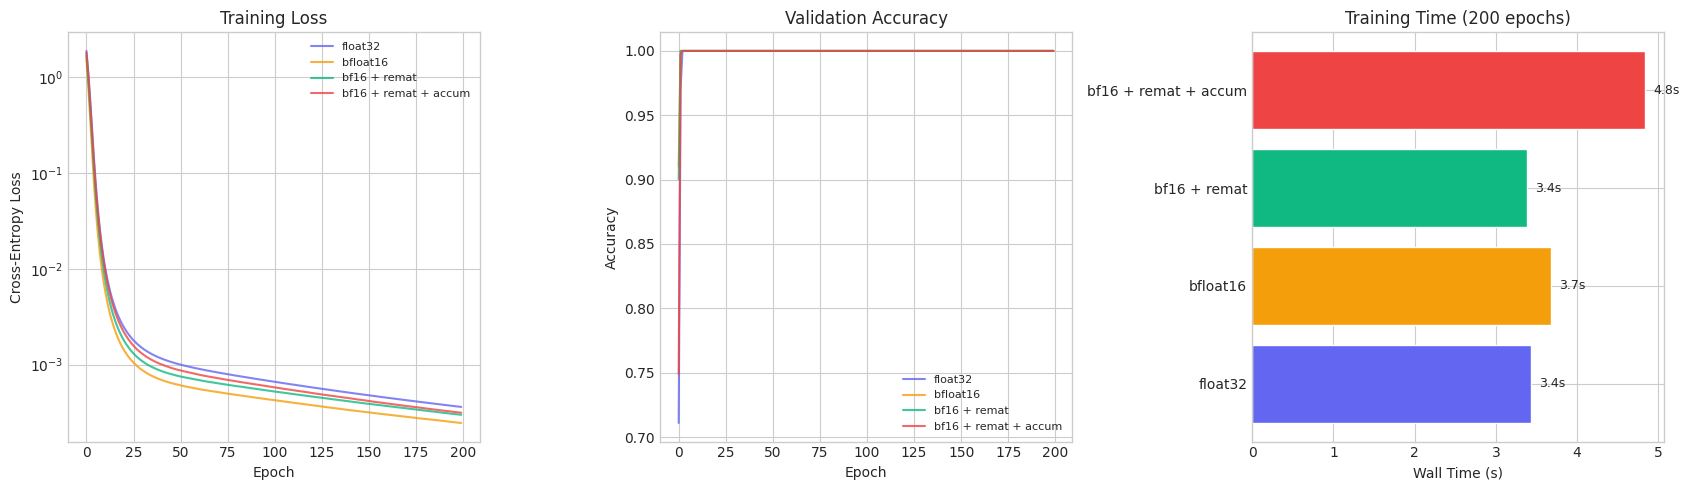

In [18]:
histories = [hist_baseline, hist_bf16, hist_remat, hist_all]
colors_plot = ["#6366f1", "#f59e0b", "#10b981", "#ef4444"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Training loss
for h, c in zip(histories, colors_plot):
    axes[0].plot(h["train_loss"], color=c, alpha=0.8, label=h["label"])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Training Loss")
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)

# Validation accuracy
for h, c in zip(histories, colors_plot):
    axes[1].plot(h["val_acc"], color=c, alpha=0.8, label=h["label"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8)

# Timing comparison
labels = [h["label"] for h in histories]
times = [h["elapsed"] for h in histories]
bars = axes[2].barh(labels, times, color=colors_plot, edgecolor="white")
for bar, t in zip(bars, times):
    axes[2].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f"{t:.1f}s", va="center", fontsize=9)
axes[2].set_xlabel("Wall Time (s)")
axes[2].set_title("Training Time (200 epochs)")

plt.tight_layout()
plt.show()

In [19]:
# Final accuracy comparison
print(f"{'Configuration':<30} {'Final Val Acc':>12} {'Time':>10}")
print("-" * 55)
for h in histories:
    print(f"{h['label']:<30} {h['val_acc'][-1]:>11.3f}% {h['elapsed']:>9.2f}s")

Configuration                  Final Val Acc       Time
-------------------------------------------------------
float32                              1.000%      3.43s
bfloat16                             1.000%      3.68s
bf16 + remat                         1.000%      3.39s
bf16 + remat + accum                 1.000%      4.83s


---

## 11 — Verifying Gradient Accumulation Correctness

A critical sanity check: gradient accumulation with $K$ mini-batches should produce **identical gradients** to a single full-batch computation (when dropout is disabled). Let's verify this explicitly.

In [20]:
# Create a deterministic model (no dropout) for exact comparison
model_check = ProteinClassifier(dtype=jnp.float32, dropout_rate=0.0)
key, check_key = random.split(key)
state_check = create_train_state(check_key, model_check)

rng_check = random.PRNGKey(99)

# Full batch gradient (1 minibatch = no accumulation)
grads_full, _ = accumulate_gradients_scan(
    state_check, train_batch, rng_check,
    num_minibatches=1, loss_fn=classification_loss_fn,
)

# Accumulated gradient (8 minibatches)
grads_accum, _ = accumulate_gradients_scan(
    state_check, train_batch, rng_check,
    num_minibatches=8, loss_fn=classification_loss_fn,
)

# Compare
max_diff = max(
    float(jnp.max(jnp.abs(g1 - g2)))
    for g1, g2 in zip(jax.tree.leaves(grads_full), jax.tree.leaves(grads_accum))
)
print(f"Max absolute difference between full-batch and accumulated gradients: {max_diff:.2e}")
print(f"Match: {max_diff < 1e-5}")

Max absolute difference between full-batch and accumulated gradients: 5.96e-08
Match: True


---

## 12 — Memory Analysis

Let's estimate the memory savings from each technique for our model. For a batch of $B$ samples with hidden size $H = 256$ and sequence/feature dimension $S = 128$:

| Component | float32 | bfloat16 | bf16 + remat |
|-----------|---------|----------|--------------|
| Dense input ($B \times S$) | $4BS$ | $2BS$ | $2BS$ (stored) |
| Dense output ($B \times H$) | $4BH$ | $2BH$ | recomputed |
| LayerNorm stats ($B \times H$) | $4BH$ | $2BH$ | recomputed |
| SiLU input ($B \times H$) | $4BH$ | $2BH$ | recomputed |
| Dropout mask ($B \times H$) | $BH$ | $BH$ | recomputed |
| **Per-block total** | $4BS + 13BH$ | $2BS + 7BH$ | $2BS$ |

With gradient accumulation ($K$ mini-batches), the effective $B$ in these formulas becomes $B/K$, giving another $K\times$ reduction in activation memory.

In [21]:
B = n_train  # batch size
S = N_FEATURES  # input features
H = 256  # hidden size
n_blocks = 2

def estimate_activation_memory(batch_size, dtype_bytes, use_remat=False):
    """Estimate activation memory per block in bytes."""
    if use_remat:
        # Only store block input
        return dtype_bytes * batch_size * S * n_blocks
    else:
        # Store all intermediates
        per_block = (dtype_bytes * batch_size * S  # dense input
                     + dtype_bytes * batch_size * H * 3  # dense out + LN + SiLU
                     + batch_size * H)  # dropout mask (1 byte)
        return per_block * n_blocks

configs = [
    ("float32, full batch", B, 4, False, 1),
    ("bfloat16, full batch", B, 2, False, 1),
    ("bf16 + remat, full batch", B, 2, True, 1),
    ("bf16 + remat + 8× accum", B, 2, True, 8),
]

print(f"{'Configuration':<35} {'Act. Memory':>12} {'Reduction':>10}")
print("-" * 60)
baseline_mem = None
for name, batch_size, dtype_bytes, use_remat, n_accum in configs:
    effective_batch = batch_size // n_accum
    mem = estimate_activation_memory(effective_batch, dtype_bytes, use_remat)
    if baseline_mem is None:
        baseline_mem = mem
    reduction = baseline_mem / mem
    print(f"{name:<35} {mem / 1024**2:>9.1f} MB {reduction:>9.1f}×")

Configuration                        Act. Memory  Reduction
------------------------------------------------------------
float32, full batch                      22.5 MB       1.0×
bfloat16, full batch                     12.0 MB       1.9×
bf16 + remat, full batch                  1.5 MB      15.0×
bf16 + remat + 8× accum                   0.2 MB     120.0×


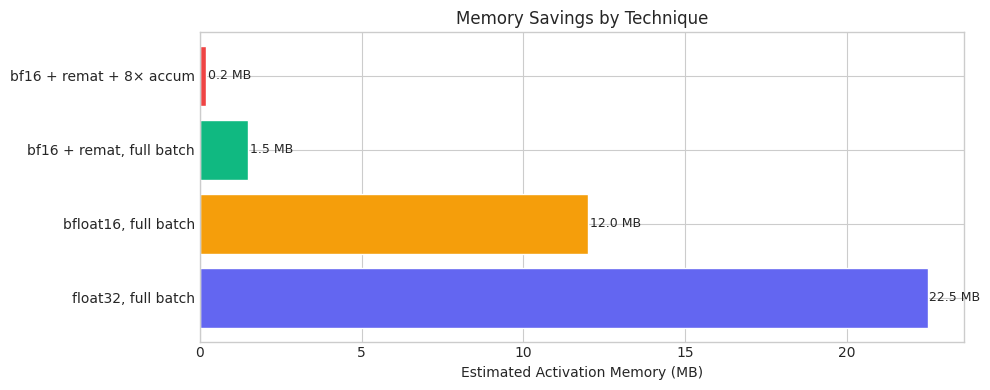

In [22]:
# Visualize memory savings
labels_mem = [c[0] for c in configs]
mems = []
for name, batch_size, dtype_bytes, use_remat, n_accum in configs:
    effective_batch = batch_size // n_accum
    mems.append(estimate_activation_memory(effective_batch, dtype_bytes, use_remat) / 1024**2)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels_mem, mems, color=colors_plot, edgecolor="white")
for bar, m in zip(bars, mems):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{m:.1f} MB", va="center", fontsize=9)
ax.set_xlabel("Estimated Activation Memory (MB)")
ax.set_title("Memory Savings by Technique")
plt.tight_layout()
plt.show()

---

## Summary

We trained a protein subcellular localization classifier using four complementary memory-saving techniques:

| Technique | Mechanism | Memory Impact | Speed Impact |
|-----------|-----------|---------------|--------------|
| **Mixed Precision** (bfloat16) | Half-precision activations with full-precision params | ~2× activation reduction | Faster on GPU/TPU |
| **Gradient Checkpointing** (remat) | Discard & recompute activations in backward pass | ~90% activation savings per block | ~30% extra compute |
| **Gradient Accumulation** (scan) | Split batch into K mini-batches | K× activation reduction | K× slower per step |
| **Buffer Donation** | Reuse input buffers for outputs in JIT | Lower peak allocation | No overhead |

**Key takeaways**:

- **bfloat16** is a drop-in replacement for float32 — same dynamic range, no loss scaling needed
- **remat** saves memory proportional to network depth — essential for deep transformers
- **Gradient accumulation** simulates arbitrary batch sizes within fixed memory — use `jax.lax.scan` for efficient compilation
- **Buffer donation** is free performance — always use `donate_argnames` for state objects
- These techniques **compose multiplicatively** — combining all four enables training models that would otherwise exceed GPU memory